Importing Test & Train Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Load data from a CSV file
train_data = pd.read_csv('/content/drive/MyDrive/DS 3003 - ML/train_data.csv')
test_data = pd.read_csv('/content/drive/MyDrive/DS 3003 - ML/test_data.csv')

# **Random Forest Regression**

Importing Libraries

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
from scipy import stats
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

Defining Numerical & Categorical Variables

In [ ]:
# Selecting Numerical and Categorical Variables Manually
numerical_features = ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss']
categorical_features = ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'income']

Splitting Target & Predictors

In [ ]:
X_train = train_data.drop(columns=['hours.per.week'])
y_train = train_data['hours.per.week']
X_test = test_data.drop(columns=['hours.per.week'])
y_test = test_data['hours.per.week']

RF Model 1 (Regression without Scaling)

In [ ]:
# Define the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [ ]:
# Append the preprocessor and the regressor to the pipeline
rfmodel = Pipeline(steps=[('preprocessor', preprocessor),
                        ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))])

In [ ]:
rfmodel.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'fnlwgt',
                                                   'education.num',
                                                   'capital.gain',
                                                   'capital.loss']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass', 'education',
                                                   'marital.status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native.country',
                                                   'income'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [ ]:
# Evaluate the model
y_pred = rfmodel.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = r2_score(y_test, y_pred)

# Display the results
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'Mean Absolute Percentage Error (MAPE): {mape}%')
print(f'R² Score: {r2}')

Mean Absolute Error (MAE): 7.1094359110169485
Mean Squared Error (MSE): 98.71919584216103
Root Mean Squared Error (RMSE): 9.935753410897487
Mean Absolute Percentage Error (MAPE): 24.997169596016334%
R² Score: 0.1735978803402637


Assessing & Scaling

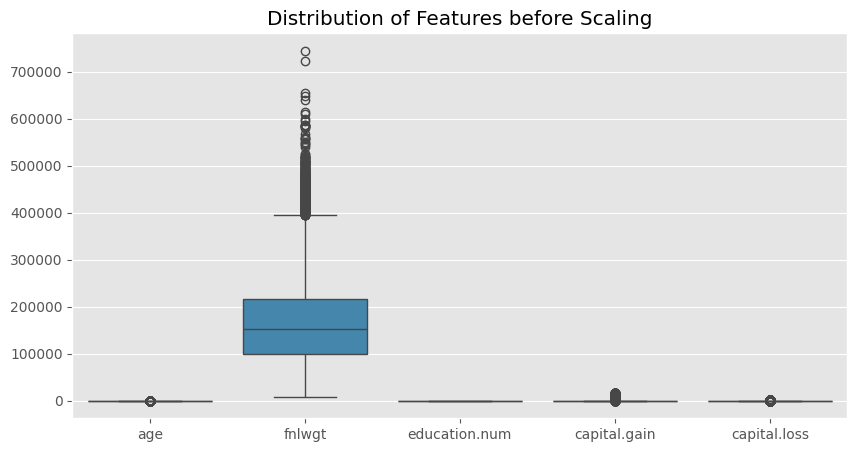

In [ ]:
plt.style.use('ggplot')
plt.figure(figsize=(10, 5))
sns.boxplot(data= X_train)
plt.title('Distribution of Features before Scaling')
plt.show()

In [ ]:
# Apply scaling only to the numerical columns
X_train_num = X_train[numerical_features]
X_test_num = X_test[numerical_features]
X_train_cat = X_train[categorical_features]
X_test_cat = X_test[categorical_features]
scaler =StandardScaler()
X_train_scaled_num = scaler.fit_transform(X_train_num)
X_test_scaled_num = scaler.transform(X_test_num)

In [ ]:
# Convert to DataFrame if it's a NumPy array
X_train_scaled_num_df = pd.DataFrame(X_train_scaled_num)

# Calculate IQR
Q1 = X_train_scaled_num_df.quantile(0.25)
Q3 = X_train_scaled_num_df.quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = ((X_train_scaled_num_df < (Q1 - 1.5 * IQR)) | (X_train_scaled_num_df > (Q3 + 1.5 * IQR)))

# Print the count of outliers in each column
print(outliers.sum())

0     150
1     368
2       0
3    1182
4    1263
dtype: int64


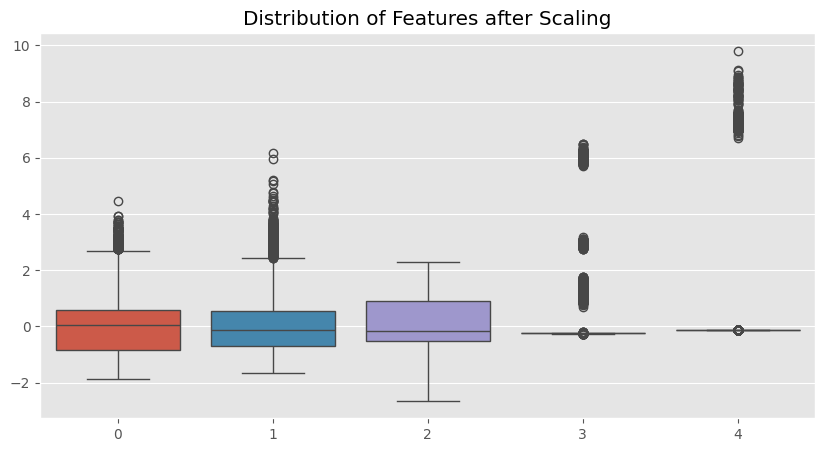

In [ ]:
#Distribution of Features after Scaling
plt.style.use('ggplot')
plt.figure(figsize=(10, 5))
sns.boxplot(data= X_train_scaled_num)
plt.title('Distribution of Features after Scaling')
plt.show()

In [ ]:
# Convert scaled numeric data back to a DataFrame
X_train_scaled_num_df = pd.DataFrame(
    X_train_scaled_num,
    columns=X_train_num.columns,
    index=X_train_num.index
)

# Concatenate scaled numeric columns with excluded categorical columns
X_train_final = pd.concat([X_train_scaled_num_df, X_train_cat], axis=1)

# Repeat the process for the test dataset
X_test_scaled_num_df = pd.DataFrame(
    X_test_scaled_num,
    columns=X_test_num.columns,
    index=X_test_num.index
)

X_test_final = pd.concat([X_test_scaled_num_df, X_test_cat], axis=1)

# Print the result to confirm
print(X_train_final.head())
print(X_test_final.head())


        age    fnlwgt  education.num  capital.gain  capital.loss  \
0  0.953840 -0.702148      -0.167931     -0.241314     -0.131384   
1  2.747076 -0.343297       0.893553      2.896295     -0.131384   
2  0.057222  0.835624       1.247381     -0.232147     -0.131384   
3  2.747076  0.175062       0.893553      2.976715     -0.131384   
4 -1.138269  1.168543       0.893553     -0.239231     -0.131384   

       workclass      education marital.status         occupation  \
0        Private        HS-grad      unmarried      Other-service   
1  Self-employed  degree-holder        married              Sales   
2        Private  degree-holder        married   Transport-moving   
3     Government  degree-holder        married     Prof-specialty   
4        Private  degree-holder      unmarried     Prof-specialty   

  relationship    race      sex native.country  income  
0    Unmarried   White     Male            USA   <=50K  
1      Husband   White     Male            USA    >50K  
2    

RF Model 2 (Regression with Scaling)

In [ ]:
# Define the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [ ]:
# Append the preprocessor and the regressor to the pipeline
rfmodel2 = Pipeline(steps=[('preprocessor', preprocessor),
                        ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))])

In [ ]:
rfmodel2.fit(X_train_final, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'fnlwgt',
                                                   'education.num',
                                                   'capital.gain',
                                                   'capital.loss']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass', 'education',
                                                   'marital.status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native.country',
                                                   'income'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [ ]:
# Evaluate the model
y_pred2 = rfmodel2.predict(X_test_final)
mae = mean_absolute_error(y_test, y_pred2)
mse = mean_squared_error(y_test, y_pred2)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred2) / y_test)) * 100
r2 = r2_score(y_test, y_pred2)

# Display the results
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'Mean Absolute Percentage Error (MAPE): {mape}%')
print(f'R² Score: {r2}')


Mean Absolute Error (MAE): 7.113866525423728
Mean Squared Error (MSE): 98.76455466101694
Root Mean Squared Error (RMSE): 9.938035754665856
Mean Absolute Percentage Error (MAPE): 24.99677270870819%
R² Score: 0.1732181707637419


RF Model 3 (Classification with Categorized Target)

In [ ]:
# Define bins and labels
bins = [float('-inf'), 40, float('inf')]
labels = ['Low', 'High']

# Create a new column with categorized data
train_data['work.hours.cat'] = pd.cut(train_data['hours.per.week'], bins=bins, labels=labels, right=False)
y_train_cat=train_data['work.hours.cat']
test_data['work.hours.cat'] = pd.cut(test_data['hours.per.week'], bins=bins, labels=labels, right=False)
y_test_cat=test_data['work.hours.cat']


In [ ]:
percentage_counts = y_train_cat.value_counts(normalize=True) * 100
print(percentage_counts)

work.hours.cat
Low     61.317445
High    38.682555
Name: proportion, dtype: float64


In [ ]:
# Define the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [ ]:
# Append the preprocessor and the regressor to the pipeline
rfmodel3_cat = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))])

In [ ]:
rfmodel3_cat.fit(X_train_final, y_train_cat)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'fnlwgt',
                                                   'education.num',
                                                   'capital.gain',
                                                   'capital.loss']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass', 'education',
                                                   'marital.status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native.country',
                                                   'income'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [ ]:
y_pred3 = rfmodel3_cat.predict(X_test_final)

score = accuracy_score(y_test_cat, y_pred3)
cr = classification_report(y_test_cat,y_pred3)

print("Random Forest")
print ("Accuracy Score value: {:.4f}".format(score))
print (cr)

print('Accuracy of Random Forest classifier on training set: {:.4f}'
     .format(rfmodel3_cat.score(X_train_final, y_train_cat)))
print('Accuracy of Random Forest classifier on test set: {:.4f}'
     .format(rfmodel3_cat.score(X_test_final, y_test_cat)))



Random Forest
Accuracy Score value: 0.8064
                 precision    recall  f1-score   support

Not Over Worked       0.83      0.94      0.89      2985
    Over Worked       0.57      0.29      0.39       791

       accuracy                           0.81      3776
      macro avg       0.70      0.62      0.64      3776
   weighted avg       0.78      0.81      0.78      3776

Accuracy of Random Forest classifier on training set: 1.0000
Accuracy of Random Forest classifier on test set: 0.8064


In [ ]:
# Define the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Append the preprocessor and the regressor to the pipeline
rfmodel3_cat = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))])

params = {
    "classifier__n_estimators": [100, 200, 300],  # Number of trees in the forest
    "classifier__criterion": ["gini", "entropy"],  # Function to measure the quality of a split
    "classifier__max_depth": [None] + list(range(5, 21, 5)),  # Maximum depth of the tree
    "classifier__min_samples_leaf": range(1, 5),  # Minimum number of samples required to be at a leaf node
    "classifier__min_samples_split": range(2, 6),  # Minimum number of samples required to split an internal node
    "classifier__max_features": ["sqrt", "log2", None]  # Number of features to consider when looking for the best split
}

rfmodel3_cat_tuned = RandomizedSearchCV(rfmodel3_cat, params, cv=10, n_jobs=-1, random_state=42)
rfmodel3_cat_tuned.fit(X_train_final, y_train_cat)

RandomizedSearchCV(cv=10,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               'passthrough',
                                                                               ['age',
                                                                                'fnlwgt',
                                                                                'education.num',
                                                                                'capital.gain',
                                                                                'capital.loss']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['workclass',
                                                                                'education',
                                                                                'marital.status',
                                                                                'occupation',
                                                                                'relationship',
                                                                                'race',
                                                                                'sex',
                                                                                'native.country',
                                                                                'income'])])),
                                             ('clas...
                                              RandomForestClassifier(class_weight='balanced',
                                                                     random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'classifier__criterion': ['gini',
                                                                  'entropy'],
                                        'classifier__max_depth': [None, 5, 10,
                                                                  15, 20],
                                        'classifier__max_features': ['sqrt',
                                                                     'log2',
                                                                     None],
                                        'classifier__min_samples_leaf': range(1, 5),
                                        'classifier__min_samples_split': range(2, 6),
                                        'classifier__n_estimators': [100, 200,
                                                                     300]},
                   random_state=42)

In [ ]:
#Store Best Model
rfmodel3_cat_best = rfmodel3_cat_tuned.best_estimator_

#Evaluate Best Model
y_pred3_tuned = rfmodel3_cat_tuned.predict(X_test_final)
best_score = accuracy_score(y_test_cat, y_pred3_tuned)
cr_tuned = classification_report(y_test_cat, y_pred3_tuned)
best_params = rfmodel3_cat_tuned.best_params_

#Best Model & Performance
print("FINAL Random Forest")
print("Best Hyperparameters:", best_params)
print("Accuracy Score value: {:.4f}".format(best_score))

print(cr_tuned)

print('Accuracy of Best Random Forest classifier on training set: {:.4f}'
      .format(rfmodel3_cat_best.score(X_train_final, y_train_cat)))
print('Accuracy of Best Random Forest classifier on test set: {:.4f}'
      .format(rfmodel3_cat_best.score(X_test_final, y_test_cat)))

FINAL Random Forest
Best Hyperparameters: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 3, 'classifier__max_features': None, 'classifier__max_depth': None, 'classifier__criterion': 'gini'}
Accuracy Score value: 0.7966
                 precision    recall  f1-score   support

Not Over Worked       0.85      0.90      0.87      2985
    Over Worked       0.52      0.42      0.47       791

       accuracy                           0.80      3776
      macro avg       0.69      0.66      0.67      3776
   weighted avg       0.78      0.80      0.79      3776

Accuracy of Best Random Forest classifier on training set: 0.9750
Accuracy of Best Random Forest classifier on test set: 0.7966


Resampling to Balance Target Categories

In [ ]:
from imblearn.over_sampling import SMOTENC
from collections import Counter

# Apply SMOTE to training data
categorical_features = ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'income']
smotenc = SMOTENC(categorical_features=categorical_features,random_state=42)
X_resampled, y_resampled = smotenc.fit_resample(X_train_final, y_train_cat)

print(f"Resampled dataset class distribution: {Counter(y_resampled)}")

Resampled dataset class distribution: Counter({'High': 9262, 'Low': 9262})


In [ ]:
# Define the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [ ]:
# Append the preprocessor and the regressor to the pipeline
rfmodel3_cat_resampled = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42))])

In [ ]:
rfmodel3_cat_resampled.fit(X_resampled, y_resampled)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'fnlwgt',
                                                   'education.num',
                                                   'capital.gain',
                                                   'capital.loss']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass', 'education',
                                                   'marital.status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native.country',
                                                   'income'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [ ]:
# Define the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Append the preprocessor and the regressor to the pipeline
rfmodel3_cat_resampled = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', RandomForestClassifier(random_state=42))])

params = {
    "classifier__n_estimators": [200, 400, 600],  # Increase trees for stability but avoid excessive computation
    "classifier__criterion": ["gini", "entropy"],  # Standard split criteria
    "classifier__max_depth": [None, 15, 25],  # Limits tree depth for better generalization
    "classifier__min_samples_leaf": range(2, 7),  # Prevents small leaf nodes that cause overfitting
    "classifier__min_samples_split": range(5, 15, 2),  # Requires more samples to split, reducing variance
    "classifier__max_features": ["sqrt", "log2"],  # Limits feature selection to avoid overfitting
    "classifier__class_weight": [None, "balanced", "balanced_subsample"]  # Handles slight class imbalance
}



rfmodel3_cat_resampled_tuned = RandomizedSearchCV(rfmodel3_cat_resampled, params, cv=10, n_jobs=-1, random_state=42)
rfmodel3_cat_resampled_tuned.fit(X_resampled, y_resampled)


RandomizedSearchCV(cv=10,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               'passthrough',
                                                                               ['age',
                                                                                'fnlwgt',
                                                                                'education.num',
                                                                                'capital.gain',
                                                                                'capital.loss']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['workclass',
                                                                                'education',
                                                                                'marital.status',
                                                                                'occupation',
                                                                                'relationship',
                                                                                'race',
                                                                                'sex',
                                                                                'native.country',
                                                                                'income'])])),
                                             ('clas...
                   param_distributions={'classifier__class_weight': [None,
                                                                     'balanced',
                                                                     'balanced_subsample'],
                                        'classifier__criterion': ['gini',
                                                                  'entropy'],
                                        'classifier__max_depth': [None, 15, 25],
                                        'classifier__max_features': ['sqrt',
                                                                     'log2'],
                                        'classifier__min_samples_leaf': range(2, 7),
                                        'classifier__min_samples_split': range(5, 15, 2),
                                        'classifier__n_estimators': [200, 400,
                                                                     600]},
                   random_state=42)

In [ ]:
#Store Best Model
rfmodel3_cat_resampled_best = rfmodel3_cat_resampled_tuned.best_estimator_

#Evaluate Best Model
y_pred3_resampled_tuned = rfmodel3_cat_resampled_tuned.predict(X_test_final)
best_score = accuracy_score(y_test_cat, y_pred3_resampled_tuned)
cr_tuned = classification_report(y_test_cat, y_pred3_resampled_tuned)
best_params = rfmodel3_cat_resampled_tuned.best_params_

#Best Model & Performance
print("FINAL Random Forest")
print("Best Hyperparameters:", best_params)
print("Accuracy Score value: {:.4f}".format(best_score))

print(cr_tuned)

print('Accuracy of Best Random Forest classifier on training set: {:.4f}'
      .format(rfmodel3_cat_resampled_best.score(X_resampled, y_resampled)))
print('Accuracy of Best Random Forest classifier on test set: {:.4f}'
      .format(rfmodel3_cat_resampled_best.score(X_test_final, y_test_cat)))

FINAL Random Forest
Best Hyperparameters: {'classifier__n_estimators': 400, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 3, 'classifier__max_features': 'sqrt', 'classifier__max_depth': None, 'classifier__criterion': 'entropy', 'classifier__class_weight': None}
Accuracy Score value: 0.6912
              precision    recall  f1-score   support

        High       0.60      0.64      0.62      1481
         Low       0.76      0.72      0.74      2295

    accuracy                           0.69      3776
   macro avg       0.68      0.68      0.68      3776
weighted avg       0.70      0.69      0.69      3776

Accuracy of Best Random Forest classifier on training set: 0.8669
Accuracy of Best Random Forest classifier on test set: 0.6912


In [ ]:
# Define the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Append the preprocessor and the regressor to the pipeline
rfmodel3_cat_resampled_set = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=10,
        min_samples_split=10,
        max_features='sqrt',
        bootstrap=True,
        class_weight='balanced',
        random_state=42
    ))
])

In [ ]:
rfmodel3_cat_resampled_set.fit(X_resampled, y_resampled)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'fnlwgt',
                                                   'education.num',
                                                   'capital.gain',
                                                   'capital.loss']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass', 'education',
                                                   'marital.status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native.country',
                                                   'income'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        min_samples_leaf=10,
                                        min_samples_split=10, n_estimators=200,
                                        random_state=42))])

In [ ]:
y_pred3_set = rfmodel3_cat_resampled_set.predict(X_test_final)

score = accuracy_score(y_test_cat, y_pred3_set)
cr = classification_report(y_test_cat,y_pred3_set)

print("Random Forest")
print ("Accuracy Score value: {:.4f}".format(score))
print (cr)

print('Accuracy of Random Forest classifier on training set: {:.4f}'
     .format(rfmodel3_cat_resampled_set.score(X_resampled, y_resampled)))
print('Accuracy of Random Forest classifier on test set: {:.4f}'
     .format(rfmodel3_cat_resampled_set.score(X_test_final, y_test_cat)))



Random Forest
Accuracy Score value: 0.6811
              precision    recall  f1-score   support

        High       0.58      0.67      0.62      1481
         Low       0.76      0.69      0.72      2295

    accuracy                           0.68      3776
   macro avg       0.67      0.68      0.67      3776
weighted avg       0.69      0.68      0.68      3776

Accuracy of Random Forest classifier on training set: 0.7276
Accuracy of Random Forest classifier on test set: 0.6811


In [ ]:
from sklearn.metrics import roc_auc_score

# Predictions on training set
y_train_pred_proba = rfmodel3_cat_resampled_set.predict_proba(X_resampled)
y_train_pred = rfmodel3_cat_resampled_set.predict(X_resampled)

# Classification report and AUC-ROC for training set
print("Training Set:")
print(classification_report(y_resampled, y_train_pred))
try:
    roc_auc_train = roc_auc_score(y_resampled, y_train_pred_proba[:, 1])
    print(f"AUC-ROC Score (Training): {roc_auc_train}")
except ValueError:
    print("AUC-ROC not computable for training set")
print(f"Accuracy (Training): {accuracy_score(y_resampled, y_train_pred)}")


# Predictions on test set
y_test_pred_proba = rfmodel3_cat_resampled_set.predict_proba(X_test_final)
y_test_pred = rfmodel3_cat_resampled_set.predict(X_test_final)

# Classification report and AUC-ROC for test set
print("\nTest Set:")
print(classification_report(y_test_cat, y_test_pred))
try:
    roc_auc_test = roc_auc_score(y_test_cat, y_test_pred_proba[:, 1])
    print(f"AUC-ROC Score (Test): {roc_auc_test}")
except ValueError:
    print("AUC-ROC not computable for test set")
print(f"Accuracy (Test): {accuracy_score(y_test_cat, y_test_pred)}")


Training Set:
              precision    recall  f1-score   support

        High       0.73      0.73      0.73      9262
         Low       0.73      0.73      0.73      9262

    accuracy                           0.73     18524
   macro avg       0.73      0.73      0.73     18524
weighted avg       0.73      0.73      0.73     18524

AUC-ROC Score (Training): 0.8042327657150387
Accuracy (Training): 0.7275966313971065

Test Set:
              precision    recall  f1-score   support

        High       0.58      0.67      0.62      1481
         Low       0.76      0.69      0.72      2295

    accuracy                           0.68      3776
   macro avg       0.67      0.68      0.67      3776
weighted avg       0.69      0.68      0.68      3776

AUC-ROC Score (Test): 0.7462501783667927
Accuracy (Test): 0.6811440677966102


In [ ]:
# prompt: How to use this model in a realworld scenerio

import pandas as pd
# Assuming rfmodel3_cat_resampled_set is your best trained model.
# Create a dictionary representing a new individual
new_individual = {
    'age': 35,
    'fnlwgt': 180000,
    'education.num': 16,
    'capital.gain': 0,
    'capital.loss': 0,
    'workclass': 'Self-employed',
    'education': 'Bachelors',
    'marital.status': 'Married-civ-spouse',
    'occupation': 'Exec-managerial',
    'relationship': 'Husband',
    'race': 'Black',
    'sex': 'Female',
    'native.country': 'United-States',
    'income': '<=50K'
}
new_df = pd.DataFrame([new_individual])  #Convert to dataframe

# Perform prediction
predicted_work_hours_category = rfmodel3_cat_resampled_set.predict(new_df)
print(f"Predicted work hours category: {predicted_work_hours_category[0]}")


Predicted work hours category: High


<ipython-input-141-ee186ac45c88>:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=aggregated_importance_df, palette='viridis')


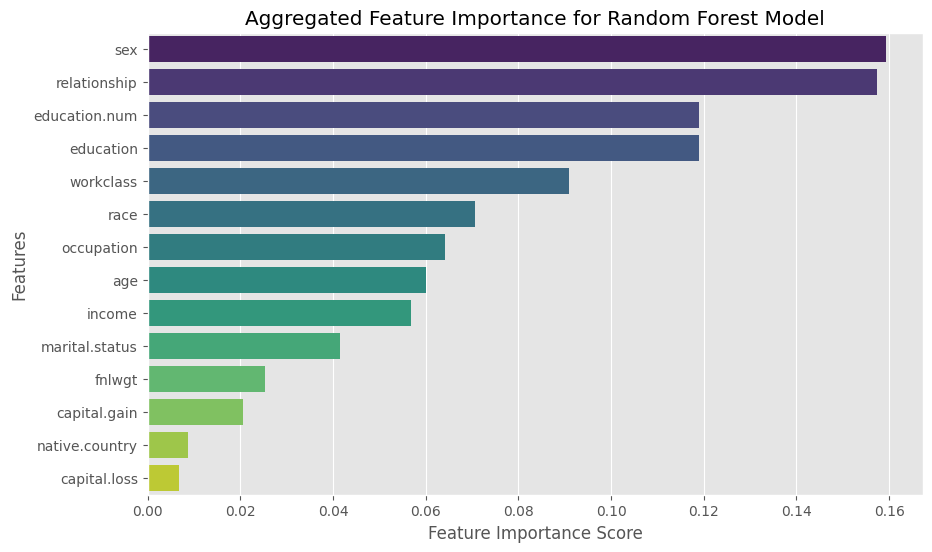

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Get feature importance from trained Random Forest model
importances = rfmodel3_cat_resampled_set.named_steps['classifier'].feature_importances_

# Fit the preprocessor on the resampled data
rfmodel3_cat_resampled_set.named_steps['preprocessor'].fit(X_resampled)

# Get feature names from the preprocessor (these are transformed names)
transformed_feature_names = rfmodel3_cat_resampled_set.named_steps['preprocessor'].get_feature_names_out()

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({'Feature': transformed_feature_names, 'Importance': importances})

# Aggregate feature importances for categorical features
# Get the original categorical feature names
categorical_features = ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'income']
# Initialize a dictionary to store aggregated importances
aggregated_importances = {}

# Iterate through transformed features and aggregate importances
for feature, importance in zip(feature_importance_df['Feature'], feature_importance_df['Importance']):
    # Check if the feature is a categorical dummy
    for cat_feature in categorical_features:
        if feature.startswith(f'cat__{cat_feature}'):
            aggregated_importances[cat_feature] = aggregated_importances.get(cat_feature, 0) + importance
            break
    else:  # If not a categorical dummy, it's a numerical feature
        aggregated_importances[feature.replace('num__', '')] = importance

# Create a DataFrame for aggregated importances
aggregated_importance_df = pd.DataFrame(list(aggregated_importances.items()), columns=['Feature', 'Importance'])

# Sort values by importance
aggregated_importance_df = aggregated_importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.barplot(x='Importance', y='Feature', data=aggregated_importance_df, palette='viridis')

plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Aggregated Feature Importance for Random Forest Model")
plt.show()

In [ ]:
# prompt: plot a PDP plot for the rfmodel3_cat_resampled_set

import matplotlib.pyplot as plt
!pip install pdpbox --upgrade  # Upgrade pdpbox to the latest version
from pdpbox import pdp, info_plots # Remove get_dataset as it is no longer available

# Assuming X_test_final and rfmodel3_cat_resampled_set are defined as in your provided code.

# Choose a feature for the PDP plot
feature_name = 'age'  # Replace with the desired feature

# Create the PDP plot
# Instead of using 'get_dataset', directly use X_test_final
pdp_plot = pdp.pdp_isolate(
    model=rfmodel3_cat_resampled_set,
    dataset=X_test_final,
    model_features=X_test_final.columns,
    feature=feature_name
)

# Plot the PDP
pdp.pdp_plot(pdp_plot, feature_name)
plt.show()

AttributeError: module 'pdpbox.pdp' has no attribute 'pdp_isolate'

In [ ]:
from scipy import stats
import numpy as np

# Get predicted probabilities for the positive class ('High' in your case)
y_probs = rfmodel3_cat_resampled_set.predict_proba(X_test_final)[:, 1]

# Separate probabilities for positive and negative classes in the test set
positive_probs = y_probs[y_test_cat == 'High']  # Probabilities for actual 'High' cases
negative_probs = y_probs[y_test_cat == 'Low']   # Probabilities for actual 'Low' cases

# Perform the KS test
ks_statistic, p_value = stats.ks_2samp(positive_probs, negative_probs)

# Print the results
print(f"KS Statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("Reject H₀: The model has good discriminatory power.")
else:
    print("Fail to reject H₀: The model's discriminatory power is questionable.")

KS Statistic: 0.3646
P-value: 0.0000
Reject H₀: The model has good discriminatory power.


In [ ]:
from scipy.stats import chi2
import numpy as np
import pandas as pd

# Get predicted probabilities
y_prob = rfmodel3_cat_resampled_set.predict_proba(X_test_final)[:, 1]  # Probability of positive class

# Divide into 10 groups based on predicted probabilities
# Adjust for potential issues with empty deciles
deciles = pd.qcut(y_prob, 10, labels=False, duplicates="drop")

# Initialize lists to hold observed and expected frequencies
observed, expected = [], []

# Loop over the deciles and calculate observed and expected values
for i in range(10):
    group_indices = np.where(deciles == i)[0]
    if len(group_indices) == 0:
        continue  # Skip empty deciles
    observed.append(np.sum(y_test_cat.iloc[group_indices] == 'High'))
    expected.append(np.sum(y_prob[group_indices]))

# Convert lists to numpy arrays for calculation
observed = np.array(observed)
expected = np.array(expected)

# Ensure that expected values are not too small (to avoid division by zero)
expected = np.clip(expected, a_min=1e-10, a_max=None)

# Compute the Hosmer-Lemeshow Test Statistic
HL_statistic = np.sum((observed - expected) ** 2 / expected)

# Calculate the p-value based on the Chi-Square distribution with 8 degrees of freedom (10 deciles - 2)
p_value = 1 - chi2.cdf(HL_statistic, df=8)

# Output the results
print(f"Hosmer-Lemeshow Test Statistic: {HL_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
if p_value > 0.05:
    print("Fail to reject H₀: The model is well calibrated.")
else:
    print("Reject H₀: The model is poorly calibrated.")

Hosmer-Lemeshow Test Statistic: 1656.8772
P-value: 0.0000
Reject H₀: The model is poorly calibrated.


# Logistic Regression

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics

In [ ]:
# Load data from a CSV file
train_data = pd.read_csv('/content/train_data.csv')
test_data = pd.read_csv('/content/test_data.csv')

In [ ]:
train_data = train_data.drop(columns=['education.num','relationship'])
test_data = test_data.drop(columns=['education.num','relationship'])

In [ ]:
train_data.head()

,age,workclass,fnlwgt,education,marital.status,occupation,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,52,Private,98926,HS-grad,unmarried,Other-service,White,Male,-3,0,44,USA,<=50K
1,76,Self-employed,132607,degree-holder,married,Sales,White,Male,7527,0,44,USA,>50K
2,40,Private,243258,degree-holder,married,Transport-moving,Other,Male,19,0,57,USA,>50K
3,76,Government,181259,degree-holder,married,Prof-specialty,White,Male,7720,0,44,USA,>50K
4,24,Private,274505,degree-holder,unmarried,Prof-specialty,White,Female,2,0,40,USA,<=50K


In [ ]:
# Define bins and labels
bins = [float('-inf'), 40, float('inf')]
labels = ['Low', 'High']

# Create a new column with categorized data
train_data['hours_category'] = pd.cut(train_data['hours.per.week'], bins=bins, labels=labels, right=False)
y_train=train_data['hours_category']
test_data['hours_category'] = pd.cut(test_data['hours.per.week'], bins=bins, labels=labels, right=False)
y_test=test_data['hours_category']

In [ ]:
# Select features and target variable
X_train = train_data.drop(['hours.per.week', 'hours_category'], axis=1)
y_train = train_data['hours_category']
X_test = test_data.drop(['hours.per.week', 'hours_category'], axis=1)
y_test = test_data['hours_category']

In [ ]:
print(train_data['hours_category'].value_counts())
percentage_counts = train_data['hours_category'].value_counts(normalize=True) * 100
print(percentage_counts)


hours_category
Low     9262
High    5843
Name: count, dtype: int64
hours_category
Low     61.317445
High    38.682555
Name: proportion, dtype: float64


In [ ]:
# Identify categorical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns


In [ ]:
# Convert categorical features to numerical using Label Encoding
for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])


In [ ]:
# Scale numerical features (important for logistic regression)
numerical_cols_train = X_train.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X_train[numerical_cols_train] = scaler.fit_transform(X_train[numerical_cols_train])
X_test[numerical_cols_train] = scaler.fit_transform(X_test[numerical_cols_train])

In [ ]:
# Create a logistic regression model
model = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=123)

In [ ]:
# Train the model
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', random_state=123,
                   solver='liblinear')

In [ ]:
# Make predictions
y_pred = model.predict(X_test)

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred, labels = ['Low', 'High'])
report = classification_report(y_test, y_pred, labels = ['Low', 'High'])

print(f"Accuracy: {accuracy}")
print("\nConfusion Matrix:\n", confusion)
print("\nClassification Report:\n", report)


Accuracy: 0.6602224576271186

Confusion Matrix:
 [[1536  759]
 [ 524  957]]

Classification Report:
               precision    recall  f1-score   support

         Low       0.75      0.67      0.71      2295
        High       0.56      0.65      0.60      1481

    accuracy                           0.66      3776
   macro avg       0.65      0.66      0.65      3776
weighted avg       0.67      0.66      0.66      3776



In [ ]:
from scipy.stats import ks_2samp

# Assuming y_test and y_prob are defined from your logistic regression model:
# y_test: True labels (0 or 1)
# y_prob: Predicted probabilities for the positive class

# Get predicted probabilities
y_prob = model.predict_proba(X_test)[:, 1]  # Probability of positive class

# Separate probabilities for positive and negative classes in the test set
positive_probs = y_prob[y_test == 'High']  # Probabilities for actual 'High' cases
negative_probs = y_prob[y_test == 'Low']   # Probabilities for actual 'Low' cases

# Perform the KS test
ks_statistic, p_value = ks_2samp(positive_probs, negative_probs)

# Print the results
print(f"KS Statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("Reject H₀: The model has good discriminatory power.")
else:
    print("Fail to reject H₀: The model's discriminatory power is questionable.")


KS Statistic: 0.3186
P-value: 0.0000
Reject H₀: The model has good discriminatory power.


In [ ]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred, pos_label='>50', average='binary')
print(f"F1-score: {f1:.4f}")

F1-score: 0.4177


In [ ]:
# Evaluating the model
accuracy1 = metrics.accuracy_score(y_test, y_pred)
precision1 = metrics.precision_score(y_test, y_pred, average='macro')
recall1 = metrics.recall_score(y_test, y_pred, average='macro')

print("Accuracy:", accuracy1)
print("Precision:", precision1)
print("Recall:", recall1)

Accuracy: 0.6602224576271186
Precision: 0.6516616878267364
Recall: 0.6577330279399628


In [ ]:
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, precision_score, recall_score
)

In [ ]:

precision2 = precision_score(y_test, y_pred, pos_label='>40')
recall2 = recall_score(y_test, y_pred, pos_label='>40')
auc_score = roc_auc_score(y_test.map({'<=40': 0, '>40': 1}), model.predict_proba(X_test)[:, 1])

In [ ]:
print("precision2:", precision2)
print("recall2:", recall2)
print("auc_score:", auc_score)

precision2: 0.28205128205128205
recall2: 0.7169459962756052
auc_score: 0.7758090267417065


In [ ]:
print('Accuracy of logistic model on training set: {:.4f}'
      .format(model.score(X_train, y_train)))
print('Accuracy of logistic model on test set: {:.4f}'
      .format(model.score(X_test, y_test)))

Accuracy of logistic model on training set: 0.6974
Accuracy of logistic model on test set: 0.7002


In [ ]:
# --- Extracting and Interpreting Model Coefficients ---
# Get the coefficients (log-odds)
coefficients = model.coef_[0]
features = X_train.columns

In [ ]:

# Convert to odds ratios
odds_ratios = np.exp(coefficients)

In [ ]:
# Create a DataFrame for better readability
coef_df = pd.DataFrame({
    'Feature': features,
    'Log-Odds': coefficients,
    'Odds Ratio': odds_ratios
})

In [ ]:
# Display the coefficients and odds ratios
print("\nModel Coefficients (Log-Odds) and Odds Ratios:")
print(coef_df.sort_values(by='Odds Ratio', ascending=False))


Model Coefficients (Log-Odds) and Odds Ratios:
           Feature  Log-Odds  Odds Ratio
7              sex  0.632040    1.881445
1        workclass  0.458020    1.580940
6             race  0.290584    1.337208
0              age  0.235132    1.265075
5       occupation  0.158019    1.171189
11          income  0.120496    1.128056
8     capital.gain  0.102834    1.108308
4   marital.status  0.067019    1.069316
10  native.country  0.019045    1.019227
9     capital.loss -0.000181    0.999819
3        education -0.050314    0.950931
2           fnlwgt -0.185627    0.830583


In [ ]:
# --- Interpretation ---
# Example interpretation
print("\nExample Interpretation:")
for feature, odds_ratio in zip(coef_df['Feature'], coef_df['Odds Ratio']):
    if odds_ratio > 1:
        print(f"An increase in {feature} increases the odds of working >40 hours.")
    elif odds_ratio < 1:
        print(f"An increase in {feature} decreases the odds of working >40 hours.")
    else:
        print(f"{feature} has no effect on the odds of working >40 hours.")


Example Interpretation:
An increase in age increases the odds of working >50 hours.
An increase in workclass increases the odds of working >50 hours.
An increase in fnlwgt decreases the odds of working >50 hours.
An increase in education decreases the odds of working >50 hours.
An increase in marital.status increases the odds of working >50 hours.
An increase in occupation increases the odds of working >50 hours.
An increase in race increases the odds of working >50 hours.
An increase in sex increases the odds of working >50 hours.
An increase in capital.gain increases the odds of working >50 hours.
An increase in capital.loss decreases the odds of working >50 hours.
An increase in native.country increases the odds of working >50 hours.
An increase in income increases the odds of working >50 hours.


### SVM

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn import svm
from sklearn.svm import SVC
#from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn import metrics
from sklearn.metrics import classification_report

In [ ]:
# Load data from a CSV file
train_data = pd.read_csv('/content/train_data.csv')
test_data = pd.read_csv('/content/test_data.csv')

In [ ]:
# Define bins and labels for response variable
bins = [float('-inf'), 40, float('inf')]
labels = ['Low', 'High']

# Create a new column with categorized data
train_data['hours_category'] = pd.cut(train_data['hours.per.week'], bins=bins, labels=labels, right=False)
y_train=train_data['hours_category']
test_data['hours_category'] = pd.cut(test_data['hours.per.week'], bins=bins, labels=labels, right=False)
y_test=test_data['hours_category']

In [ ]:
# Select features and target variable
X_train = train_data.drop(['hours.per.week', 'hours_category'], axis=1)
y_train = train_data['hours_category']
X_test = test_data.drop(['hours.per.week', 'hours_category'], axis=1)
y_test = test_data['hours_category']

In [ ]:
# Boxcox Tranformation for 'capital.loss' (since log transformation still show a skewness)
from scipy.stats import boxcox

X_train['boxcox_capital_loss'], lambda_ = boxcox(X_train['capital.loss'] + 3) # Add 1 to handle 0 values
X_test['boxcox_capital_loss'] = boxcox(X_test['capital.loss'] + 3, lmbda=lambda_) # Use the same lambda for test data

from sklearn.preprocessing import QuantileTransformer
qt = QuantileTransformer(output_distribution='normal')
X_train[['tra_age']] = qt.fit_transform(X_train[['age']])
X_test[['tra_age']] = qt.transform(X_test[['age']])

# Boxcox Tranformation for 'fnlwgt' (since log transformation still show a skewness)
from scipy.stats import boxcox

X_train['boxcox_fnlwgt'], lambda_ = boxcox(X_train['fnlwgt'] + 1) # Add 1 to handle 0 values
X_test['boxcox_fnlwgt'] = boxcox(X_test['fnlwgt'] + 1, lmbda=lambda_) # Use the same lambda for test data


In [ ]:
# Drop the original features
features_to_drop = ['capital.loss', 'age', 'fnlwgt']
X_train = X_train.drop(columns=features_to_drop)
X_test = X_test.drop(columns=features_to_drop)

In [ ]:
# Check for missing values in X_train
missing_values = X_train.isnull().sum()
print(missing_values)

workclass              0
education              0
education.num          0
marital.status         0
occupation             0
relationship           0
race                   0
sex                    0
capital.gain           0
native.country         0
income                 0
boxcox_capital_loss    0
tra_age                0
boxcox_fnlwgt          0
dtype: int64


In [ ]:
# Identify categorical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

In [ ]:
# Initialize OneHotEncoder
ohe = OneHotEncoder(drop='first', sparse_output=False)  # Drop first to avoid multicollinearity

# Fit & transform on training data, transform on test data
X_train_ohe = ohe.fit_transform(X_train[categorical_cols])
X_test_ohe = ohe.transform(X_test[categorical_cols])

# Convert to DataFrame with correct column names
X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=ohe.get_feature_names_out(categorical_cols))
X_test_ohe_df = pd.DataFrame(X_test_ohe, columns=ohe.get_feature_names_out(categorical_cols))

# Reset index to align with the original dataset
X_train_ohe_df.index = X_train.index
X_test_ohe_df.index = X_test.index

# Drop original categorical columns and merge encoded data
X_train = pd.concat([X_train.drop(columns=categorical_cols), X_train_ohe_df], axis=1)
X_test = pd.concat([X_test.drop(columns=categorical_cols), X_test_ohe_df], axis=1)


In [ ]:
# Scale numerical features
numerical_cols_train = X_train.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X_train[numerical_cols_train] = scaler.fit_transform(X_train[numerical_cols_train])
X_test[numerical_cols_train] = scaler.transform(X_test[numerical_cols_train])


In [ ]:
# Create a SVM model with initial parameters
svm_model = SVC(kernel='rbf', C=0.1, gamma='scale', class_weight='balanced', probability=True, random_state=123)
svm_model.fit(X_train, y_train)

# Evaluate the model (e.g., using accuracy, F1-score, etc.)
y_pred = svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred, pos_label='High')
print(f"F1 Score: {f1}")

Accuracy: 0.6795550847457628
F1 Score: 0.6232876712328768


Confusion Matrix:
[[1566  729]
 [ 480 1001]]


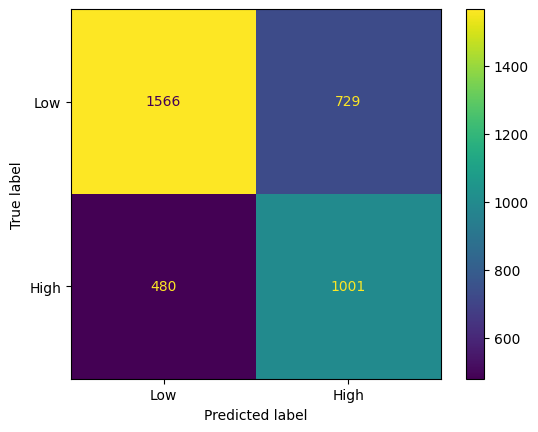

In [ ]:
# prompt: Confusion matrix for the svm model

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Import ConfusionMatrixDisplay

# Assuming y_test and y_pred are defined from your SVM model:
# y_test: True labels
# y_pred: Predicted labels

cm = confusion_matrix(y_test, y_pred, labels=['Low', 'High'])
print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'High'])
disp.plot()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the categorical features you want to analyze
features = ['occupation', 'education', 'marital.status']

# Loop through each feature and plot its PDP
for feature in features:
    unique_values = X_test[feature].unique()  # Get unique categories for the feature
    average_predictions = []

    for value in unique_values:
        X_modified = X_test.copy()
        X_modified[feature] = value
        # Get model predictions
        predictions = svm.model.predict_proba(X_modified)
        # Compute the mean probability for the "overworked" class (negative class, target=0)
        avg_prob_overwork = 1 - np.mean(predictions[:, 1])
        average_predictions.append(avg_prob_overwork)

    # Print the calculated probabilities for verification
    print(f"Average predicted probabilities for being overworked by {feature}:", average_predictions)

    # Plot the results with enhanced readability
    plt.figure(figsize=(10, 6))
    bars = plt.bar(unique_values, average_predictions, color=['#FF6666', '#66B2FF', '#FFD700', '#8A2BE2', '#FF8C00'])  # Distinct colors

    # Add exact probability values above bars
    for bar, prob in zip(bars, average_predictions):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{prob:.2%}',
                 ha='center', va='bottom', fontsize=12, color='black')

    # Enhanced plot titles and labels
    plt.title(f'Predicted Probability of Being Overworked by {feature.capitalize()}', fontsize=14)
    plt.xlabel(feature.capitalize(), fontsize=12)
    plt.ylabel('Average Predicted Probability (%)', fontsize=12)
    plt.ylim(0, 1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines for readability
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability

    # Show the plot
    plt.tight_layout()
    plt.show()

In [ ]:
# prompt: Do a KS test for model distciminatory power for the svm mode

from scipy.stats import ks_2samp

# Reorder columns to match X_train
X_test = X_test[X_train.columns]

# Now you can use this updated X_test to predict:
y_prob = svm_model.predict_proba(X_test)[:, 1]
# ... your remaining code ...

# Separate probabilities for positive and negative classes in the test set
positive_probs = y_prob[y_test == 'High']  # Probabilities for actual 'High' cases
negative_probs = y_prob[y_test == 'Low']   # Probabilities for actual 'Low' cases

# Perform the KS test
ks_statistic, p_value = ks_2samp(positive_probs, negative_probs)

# Print the results
print(f"KS Statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("Reject H₀: The model has good discriminatory power.")
else:
    print("Fail to reject H₀: The model's discriminatory power is questionable.")


KS Statistic: 0.3612
P-value: 0.0000
Reject H₀: The model has good discriminatory power.


In [ ]:
# prompt: Do a Permutation Test (Randomization Test) to check if the model is better than random guessing or not

import numpy as np
from scipy.stats import ks_2samp

def permutation_test(y_true, y_pred, n_permutations=1000):
    """
    Performs a permutation test to assess model performance against random guessing.

    Args:
        y_true: True labels.
        y_pred: Predicted labels or probabilities (if probabilities, use AUC or Brier score).
        n_permutations: Number of permutations to perform.

    Returns:
        p_value: The p-value from the permutation test.
    """

    observed_statistic = accuracy_score(y_true, y_pred)  # or other metric

    permuted_statistics = []
    for _ in range(n_permutations):
        permuted_y_true = np.random.permutation(y_true)  # shuffle the true labels
        permuted_statistic = accuracy_score(permuted_y_true, y_pred) # or other metric
        permuted_statistics.append(permuted_statistic)

    p_value = (np.sum(np.array(permuted_statistics) >= observed_statistic) + 1) / (n_permutations + 1)
    return p_value


# Example Usage (adapt to your specific model and evaluation metric):
# Assuming 'y_test' and 'y_pred' from your SVM model.

# Replace 'y_pred' with probabilities if using AUC or Brier score:
# y_pred = svm_model.predict_proba(X_test)[:, 1] # for probability based metrics

p_value = permutation_test(y_test, y_pred, n_permutations=10000)

print(f"P-value from permutation test: {p_value}")

if p_value < 0.05:
    print("The model performs significantly better than random guessing.")
else:
    print("The model's performance is not significantly different from random guessing.")


P-value from permutation test: 9.999000099990002e-05
The model performs significantly better than random guessing.


In [ ]:
# prompt: Draw a PDP for each features to identify the relationship between the target category (High) and all other variables for the SVM model

import matplotlib.pyplot as plt
!pip install pdpbox --upgrade

from pdpbox import pdp, info_plots

# Assuming X_test and svm_model are defined as in your provided code.
# Replace X_test with your actual test feature data.

# Get feature names
feature_names = X_test.columns

# Ensure X_test has the same columns and order as X_train used for training
X_test = X_test[X_train.columns]  # Reorder columns to match X_train

# Loop through features and create PDP plots
for feature_name in feature_names:
    pdp_plot = pdp.PDPIsolate(
        model=svm_model,
        df=X_test,  # Use X_test with the correct column order
        model_features=feature_names,  # Use correct feature names
        feature=feature_name,
        feature_name=feature_name,
        n_classes=2
    )

    pdp.pdp_plot(pdp_plot, feature_name)
    plt.title(f"Partial Dependence Plot for {feature_name}")
    plt.show()

In [ ]:
import inspect
from pdpbox import pdp

# Option 1: Print the signature (i.e., the constructor parameters) of PDPIsolate
print("PDPIsolate Signature:")
print(inspect.signature(pdp.PDPIsolate))

# Option 2: List all attributes and methods of PDPIsolate
print("\nAttributes and Methods of PDPIsolate:")
print(dir(pdp.PDPIsolate))

# Option 3: Display the detailed documentation (docstring) of PDPIsolate
print("\nHelp on PDPIsolate:")
help(pdp.PDPIsolate)


PDPIsolate Signature:
(model, df, model_features, feature, feature_name, pred_func=None, n_classes=None, memory_limit=0.5, chunk_size=-1, n_jobs=1, predict_kwds=None, data_transformer=None, cust_grid_points=None, grid_type='percentile', num_grid_points=10, percentile_range=None, grid_range=None)

Attributes and Methods of PDPIsolate:
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_calc_ice_lines', '_calculate', '_collect_pdp_results', '_prepare_calculate', '_prepare_feature', 'plot']

Help on PDPIsolate:
Help on class PDPIsolate in module pdpbox.pdp:

class PDPIsolate(_PDPBase)
 |  PDPIsolate(model, df, model_features, feature, feature_name, pred_func=None, n_classes=None, mem

In [ ]:
import matplotlib.pyplot as plt
from pdpbox import pdp

# Assuming X_test and svm_model are already defined
# Ensure X_test has the same columns and order as X_train used for training
X_test = X_test[X_train.columns]  # Reorder columns to match X_train

# Get feature names and identify categorical columns
feature_names = X_test.columns
categorical_features = [col for col in feature_names if X_test[col].dtype == 'object']

# Combine original categorical features and numerical features
original_features = feature_names.difference(categorical_features)

# Loop through features and create PDP plots for each feature
for feature_name in original_features:
    # Check if the feature has more than one unique value
    if X_test[feature_name].nunique() > 1:  # Add this condition
        pdp_isolate = pdp.PDPIsolate(
            model=svm_model,
            df=X_test,
            model_features=feature_names,
            feature=feature_name,
            feature_name=feature_name,
            n_classes=2
        )

        # Plot using the plot method of PDPIsolate and access the figure and axes
        fig, axes = pdp_isolate.plot(
            center=True,
            plot_lines=False,
            frac_to_plot=1,
            cluster=False,
            n_cluster_centers=None,
            cluster_method='accurate',
            plot_pts_dist=False,
            to_bins=False,
            show_percentile=False,
            which_classes=None,
            figsize=(10, 6),
            dpi=300,
            ncols=1,
            plot_params=None,
            engine='matplotlib',
            template='plotly_white'
        )

        # Set the title for the plot using fig.suptitle()
        fig.suptitle(f"Partial Dependence Plot for {feature_name}")  # Change to fig.suptitle()

        # Show the plot
        plt.show()
    else:
        print(f"Skipping PDP for {feature_name} as it has only one unique value.")


In [ ]:
print(dir(pdp))

['FeatureInfo', 'PDPInteract', 'PDPInteractPlotEngine', 'PDPIsolate', 'PDPIsolatePlotEngine', 'PDPResult', '_PDPBase', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '__warningregistry__', '_calc_n_jobs', '_calc_preds', '_check_classes', '_check_cluster_params', '_check_dataset', '_check_frac_to_plot', '_check_model', '_check_pdp_interact_plot_type', '_check_plot_engine', '_expand_params_for_interact', '_make_list', 'np', 'pd', 'pqdm', 'tqdm', 'warnings']


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Expand your parameter grid:
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['linear']
}

# Create SVM model
svm_model = SVC()

# Perform Grid Search with more detailed output:
grid_search = GridSearchCV(svm_model, param_grid, cv=5, scoring='f1', verbose=2)
grid_search.fit(X_train, y_train)

# Best Parameters
print("Best parameters:", grid_search.best_params_)
print("Best accuracy:", grid_search.best_score_)

#SVC(C=0.1, kernel='linear')

In [ ]:
# Create a SVM model with initial parameters
svm_model2 = SVC(kernel='linear', C=0.1, class_weight='balanced', probability=True, random_state=123)
svm_model2.fit(X_train, y_train)

# Evaluate the model (e.g., using accuracy, F1-score, etc.)
y_pred = svm_model2.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred, pos_label='High')
print(f"F1 Score: {f1}")

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred, labels = ['Low', 'High'])
report = classification_report(y_test, y_pred, labels = ['Low', 'High'])

print(f"Accuracy: {accuracy}")
print("\nConfusion Matrix:\n", confusion)
print("\nClassification Report:\n", report)

Accuracy: 0.6819385593220338

Confusion Matrix:
 [[1556  739]
 [ 462 1019]]

Classification Report:
               precision    recall  f1-score   support

         Low       0.77      0.68      0.72      2295
        High       0.58      0.69      0.63      1481

    accuracy                           0.68      3776
   macro avg       0.68      0.68      0.68      3776
weighted avg       0.70      0.68      0.69      3776



In [ ]:
# Calculate permutation feature importance
results = permutationimportance(svm_model, X_test, y_test, n_repeats=10, random_state=42)

# Print feature importance
for i in range(X.shape[1]):
    print(f"Feature {i}: {results.importances_mean[i]}")



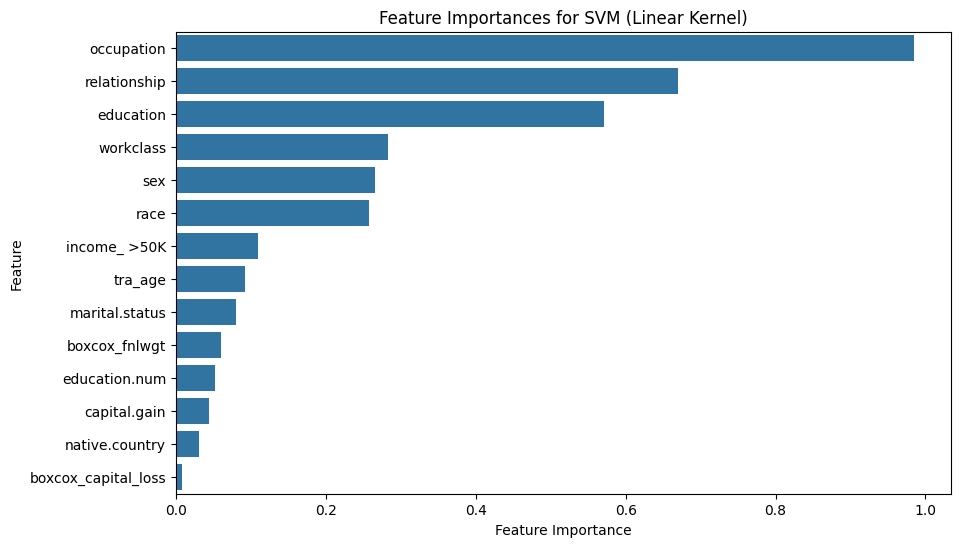

In [ ]:
# prompt: plot a feature imporatnce plot for the above SVM model. I want only the features not the dummies so aggregate

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'svm_model2' is your trained SVM model and X_train is your training data.
# You'll need to adapt the feature names if they were transformed during preprocessing.

try:
    #For linear kernel
    feature_importances = abs(svm_model2.coef_[0]) #Get the coefficients
    feature_names = X_train.columns

    # Create a DataFrame for feature importances
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

    # Aggregate feature importances for categorical features (if applicable)
    categorical_features = ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']  #Replace with your actual categorical feature names
    aggregated_importances = {}

    for feature, importance in zip(feature_importance_df['Feature'], feature_importance_df['Importance']):
        for cat_feature in categorical_features:
            if feature.startswith(f'{cat_feature}_'):
              aggregated_importances[cat_feature] = aggregated_importances.get(cat_feature, 0) + importance
              break
        else:
            aggregated_importances[feature] = importance

    # Create a DataFrame for aggregated importances
    aggregated_importance_df = pd.DataFrame(list(aggregated_importances.items()), columns=['Feature', 'Importance'])

    # Sort values by importance
    aggregated_importance_df = aggregated_importance_df.sort_values(by='Importance', ascending=False)

    # Plot the feature importances
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=aggregated_importance_df)
    plt.xlabel('Feature Importance')
    plt.ylabel('Feature')
    plt.title('Feature Importances for SVM (Linear Kernel)')
    plt.show()

except AttributeError:
    print("Feature importance is not available for the 'rbf' kernel in SVM")
    # Provide an alternative for the 'rbf' kernel, if necessary.
    # One way is to use permutation feature importance.



In [ ]:
X_test[feature].unique()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the categorical features you want to analyze
features = ['relationship', 'education', 'marital.status']

# Loop through each feature and plot its PDP
for feature in features:
    unique_values = X_test_final[feature].unique()
    # Get unique categories for the feature
    average_predictions = []

    for value in unique_values:
        X_modified = X_test_final.copy()
        X_modified[feature] = value

        # Get model predictions using predict_proba for SVM (ensure 'probability=True' when fitting svm_model2)
        predictions = svm_model2.predict_proba(X_modified)

        # Compute the mean probability for the "overworked" class (negative class, target=0)
        avg_prob_overwork = 1 - np.mean(predictions[:, 1])  # Assuming 'overworked' is class 1
        average_predictions.append(avg_prob_overwork)

    # Print the calculated probabilities for verification
    print(f"Average predicted probabilities for being overworked by {feature}:", average_predictions)

    # Plot the results with enhanced readability
    plt.figure(figsize=(10, 6))
    bars = plt.bar(unique_values, average_predictions, color=['#FF6666', '#66B2FF', '#FFD700', '#8A2BE2', '#FF8C00'])  # Distinct colors

    # Add exact probability values above bars
    for bar, prob in zip(bars, average_predictions):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{prob:.2%}',
                 ha='center', va='bottom', fontsize=12, color='black')

    # Enhanced plot titles and labels
    plt.title(f'Predicted Probability of Being Overworked by {feature.capitalize()}', fontsize=14)
    plt.xlabel(feature.capitalize(), fontsize=12)
    plt.ylabel('Average Predicted Probability (%)', fontsize=12)
    plt.ylim(0, 1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines for readability
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability

    # Show the plot
    plt.tight_layout()
    plt.show()


### RFE Feature selection

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Train the Random Forest model
model_rf = RandomForestClassifier(random_state=42)  # Initialize RandomForest
model_rf.fit(X_train, y_train)  # Fit on your training data
feature_importances = model_rf.feature_importances_

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

# Display the feature importances
print(feature_importance_df)

# Select top features
top_features = feature_importance_df['Feature'].tolist()

# Create new datasets with selected features
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

                             Feature  Importance
4                      boxcox_fnlwgt    0.170312
1                       capital.gain    0.153727
3                            tra_age    0.149585
0                      education.num    0.091116
33                         sex_ Male    0.040131
7            workclass_Self-employed    0.036470
9            education_degree-holder    0.030379
35                      income_ >50K    0.027127
2                boxcox_capital_loss    0.021962
32                       race_ White    0.020146
34            native.country_not-USA    0.016086
10            education_school-level    0.015939
6               workclass_Government    0.015862
12          marital.status_unmarried    0.015040
29           relationship_ Unmarried    0.014603
21        occupation_ Prof-specialty    0.014225
23                 occupation_ Sales    0.014166
26       relationship_ Not-in-family    0.013921
11  marital.status_separated/widowed    0.013600
15       occupation_

In [ ]:
svm_model3 = SVC(kernel='linear', C=0.1, class_weight='balanced', probability=True, random_state=123)
svm_model3.fit(X_train_selected, y_train)

# Predictions
y_pred_train = svm_model3.predict(X_train_selected)  # Predictions on training data
y_pred_test = svm_model3.predict(X_test_selected)    # Predictions on testing data

# Accuracy
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

# F1-Score
f1_test_H = f1_score(y_test, y_pred_test, pos_label='High')
f1_test_L = f1_score(y_test, y_pred_test, pos_label='Low')

# Print the results
print(f"Training Accuracy: {accuracy_train:.4f}")
print(f"Testing Accuracy: {accuracy_test:.4f}")
print(f"Test(High) F1-Score: {f1_test_H:.4f}")
print(f"Test(Low) F1-Score: {f1_test_L:.4f}")

Training Accuracy: 0.7012
Testing Accuracy: 0.6819
Test(High) F1-Score: 0.6290
Test(Low) F1-Score: 0.7217


In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred, labels = ['Low', 'High'])
report = classification_report(y_test, y_pred, labels = ['Low', 'High'])

print(f"Accuracy: {accuracy}")
print("\nConfusion Matrix:\n", confusion)
print("\nClassification Report:\n", report)

Accuracy: 0.6819385593220338

Confusion Matrix:
 [[1557  738]
 [ 463 1018]]

Classification Report:
               precision    recall  f1-score   support

         Low       0.77      0.68      0.72      2295
        High       0.58      0.69      0.63      1481

    accuracy                           0.68      3776
   macro avg       0.68      0.68      0.68      3776
weighted avg       0.70      0.68      0.69      3776



Factor Analysis for Outlier Detection

In [ ]:
!pip install prince
import pandas as pd
import prince

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.3/417.3 kB 5.9 MB/s eta 0:00:00


### Modified Code with Feature Importance Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Identify categorical and numerical features
categorical_features = ['Work-class', 'Education', 'Marital status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Native country']
numerical_features = ['Age', 'Fnlwgt', 'Education-num', 'Capital-gain', 'Capital-loss', 'Hours-per-week']

# Preprocessing: One-Hot Encoding for Categorical & Standard Scaling for Numeric Features
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features)  # Drop first to avoid multicollinearity
])

# Logistic Regression Model
log_reg = LogisticRegression(max_iter=1000)

# Feature Selection using SelectFromModel
feature_selector = SelectFromModel(log_reg, threshold='mean')  # Keeps features with importance above average

# Pipeline with Feature Selection
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', feature_selector),
    ('model', log_reg)
])

# Train Model
model_pipeline.fit(X_train, y_train)

# Get Feature Names After Encoding
encoded_feature_names = (preprocessor.named_transformers_['num'].get_feature_names_out(numerical_features).tolist() +
                         preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist())

# Get Selected Features
selected_features = np.array(encoded_feature_names)[model_pipeline.named_steps['feature_selection'].get_support()]
print("Selected Features:", selected_features)

# Predictions
y_train_pred = model_pipeline.predict(X_train)
y_test_pred = model_pipeline.predict(X_test)

# Probabilities for AUC-ROC
y_train_prob = model_pipeline.predict_proba(X_train)[:, 1]
y_test_prob = model_pipeline.predict_proba(X_test)[:, 1]

# Compute Metrics for Training Set
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, pos_label=">50")
train_recall = recall_score(y_train, y_train_pred, pos_label=">50")
train_f1 = f1_score(y_train, y_train_pred, pos_label=">50")
train_auc_roc = roc_auc_score(y_train, y_train_prob)

# Compute Metrics for Test Set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, pos_label=">50")
test_recall = recall_score(y_test, y_test_pred, pos_label=">50")
test_f1 = f1_score(y_test, y_test_pred, pos_label=">50")
test_auc_roc = roc_auc_score(y_test, y_test_prob)

# Print Performance Metrics
print("\nPerformance on Training Set:")
print(f"Accuracy: {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall: {train_recall:.4f}")
print(f"F1-Score: {train_f1:.4f}")
print(f"AUC-ROC: {train_auc_roc:.4f}")

print("\nPerformance on Test Set:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")
print(f"AUC-ROC: {test_auc_roc:.4f}")

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_prob, pos_label=">50")
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {test_auc_roc:.4f}', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend()
plt.show()


In [ ]:
train_data.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,work.hours.cat
0,52,Private,98926,HS-grad,9,unmarried,Other-service,Unmarried,White,Male,-3,0,44,USA,<=50K,Not Over Worked
1,76,Self-employed,132607,degree-holder,12,married,Sales,Husband,White,Male,7527,0,44,USA,>50K,Not Over Worked
2,40,Private,243258,degree-holder,13,married,Transport-moving,Husband,Other,Male,19,0,57,USA,>50K,Over Worked
3,76,Government,181259,degree-holder,12,married,Prof-specialty,Husband,White,Male,7720,0,44,USA,>50K,Not Over Worked
4,24,Private,274505,degree-holder,12,unmarried,Prof-specialty,Own-child,White,Female,2,0,40,USA,<=50K,Not Over Worked


In [ ]:
print(train_data.dtypes)

age                  int64
workclass           object
fnlwgt               int64
education           object
education.num        int64
marital.status      object
occupation          object
relationship        object
race                object
sex                 object
capital.gain         int64
capital.loss         int64
hours.per.week       int64
native.country      object
income              object
work.hours.cat    category
dtype: object


In [ ]:
# Convert the specified columns to float
for col in numerical_features_all:
    train_data[col] = train_data[col].astype(float)

# Verify the changes
print(train_data.dtypes)

age                float64
workclass           object
fnlwgt             float64
education           object
education.num      float64
marital.status      object
occupation          object
relationship        object
race                object
sex                 object
capital.gain       float64
capital.loss       float64
hours.per.week     float64
native.country      object
income              object
work.hours.cat    category
dtype: object


In [ ]:
# Initialize the FAMD model
famd = prince.FAMD(n_components=2, random_state=42)

# Fit the model to your data
famd = famd.fit(train_data)

# Transform the data to the new feature space
transformed_data = famd.transform(train_data)

In [ ]:
# Calculate the Euclidean distance from the origin
distances = (transformed_data ** 2).sum(axis=1) ** 0.5

# Define a threshold for outlier detection (e.g., 95th percentile)
threshold = distances.quantile(0.95)

# Identify outliers
outliers = train_data[distances > threshold]


In [ ]:
outliers

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,work.hours.cat
14,44.0,Self-employed,204336.0,degree-holder,15.0,married,Prof-specialty,Husband,White,Female,24.0,0.0,57.0,USA,>50K,Over Worked
17,32.0,Self-employed,156541.0,degree-holder,15.0,married,Sales,Husband,White,Male,16.0,0.0,65.0,USA,>50K,Over Worked
54,43.0,Self-employed,114944.0,degree-holder,12.0,married,Prof-specialty,Husband,Other,Male,8.0,0.0,65.0,USA,>50K,Over Worked
57,47.0,Self-employed,156823.0,degree-holder,13.0,married,Sales,Husband,White,Male,33.0,0.0,56.0,USA,>50K,Over Worked
75,32.0,Private,186170.0,degree-holder,13.0,married,Exec-managerial,Husband,White,Male,7473.0,0.0,60.0,USA,>50K,Over Worked
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15041,55.0,Self-employed,134493.0,degree-holder,12.0,married,Exec-managerial,Husband,White,Male,2.0,0.0,57.0,USA,>50K,Over Worked
15046,40.0,Self-employed,447055.0,degree-holder,9.0,married,Craft-repair,Husband,White,Male,14.0,0.0,55.0,USA,>50K,Over Worked
15058,77.0,Private,81630.0,degree-holder,12.0,married,Exec-managerial,Husband,White,Male,3781.0,0.0,59.0,USA,>50K,Over Worked
15070,71.0,Self-employed,156797.0,HS-grad,9.0,married,Exec-managerial,Husband,White,Male,40.0,0.0,54.0,USA,>50K,Over Worked


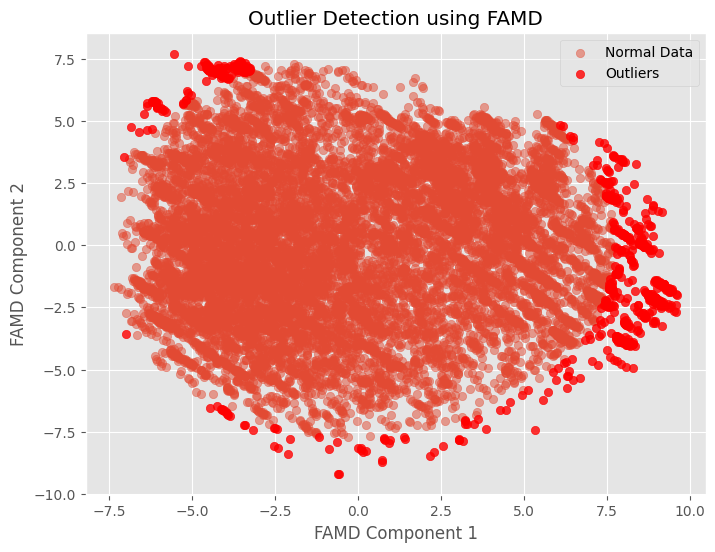

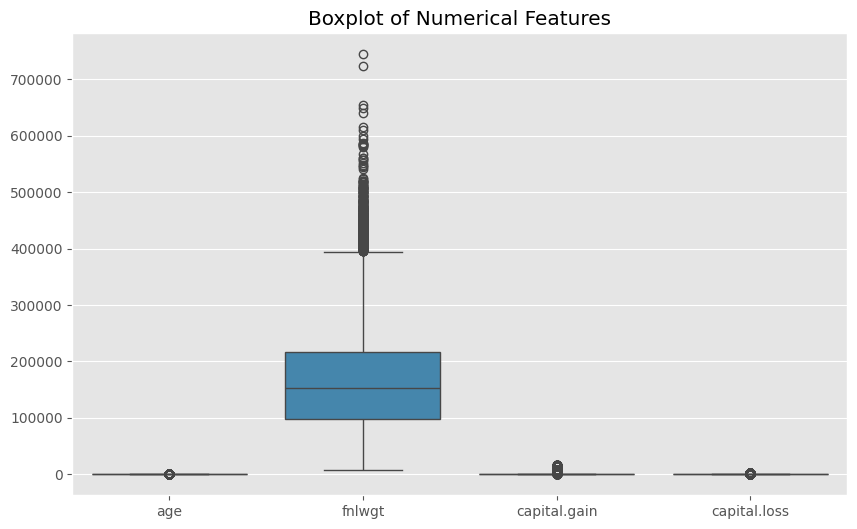

In [ ]:
import matplotlib.pyplot as plt
# Plot the outliers in the transformed feature space
plt.figure(figsize=(8, 6))
# Access columns by index instead of name
plt.scatter(transformed_data[distances <= threshold][0], transformed_data[distances <= threshold][1], label='Normal Data', alpha=0.5)
plt.scatter(transformed_data[distances > threshold][0], transformed_data[distances > threshold][1], label='Outliers', color='red', alpha=0.8)
plt.xlabel('FAMD Component 1')
plt.ylabel('FAMD Component 2')
plt.title('Outlier Detection using FAMD')
plt.legend()
plt.show()

#Alternatively, you can plot the outliers in the original feature space. For example:
plt.figure(figsize=(10, 6))
sns.boxplot(data=train_data[['age','fnlwgt', 'capital.gain', 'capital.loss']]) #replace with your features
plt.title('Boxplot of Numerical Features')
plt.show()



---



In [ ]:
#Hosmer-Lemeshow Test for Goodness of Fit for Logistics Model
#Get predicted probabilities for the test data
y_prob_log = model.predict_proba(X_test)[:, 1]

#Create deciles based on predicted probabilities
deciles = pd.qcut(y_prob_log, 10, labels=False)

#Calculate the observed and expected frequencies for each decile
observed = []
expected = []

for i in range(10):
    decile_indices = np.where(deciles == i)[0]
    if len(decile_indices) == 0:  # Skip deciles with no observations
        continue

    # Actual values (observed) for the current decile
    observed_pos = np.sum(y_test.iloc[decile_indices] == 1)  # Count of positive cases (1)
    observed_neg = np.sum(y_test.iloc[decile_indices] == 0)  # Count of negative cases (0)

    observed.append(observed_pos)
    observed.append(observed_neg)

    #Predicted probabilities (expected) for the current decile
    expected_pos = np.sum(y_prob_log[decile_indices])  #Sum of predicted probabilities for positive class (1)
    expected_neg = np.sum(1 - y_prob_log[decile_indices])  #Sum of predicted probabilities for negative class (0)

    expected.append(expected_pos)
    expected.append(expected_neg)

#Convert observed and expected arrays to numpy arrays for safe math
observed = np.array(observed)
expected = np.array(expected)

#Prevent division by zero by adding a small constant where expected is zero
expected[expected == 0] = 1e-10  # Small value to avoid division by zero

#Hosmer-Lemeshow Chi-squared Statistic
HL_statistic = np.sum((observed - expected) ** 2 / expected)

#Calculate the p-value for the test statistic
df = 8  #Degrees of freedom: 10 deciles - 2 (for each decile, we have 2 categories)
p_value = 1 - stats.chi2.cdf(HL_statistic, df)

#Results
print(f"Hosmer-Lemeshow Test Statistic: {HL_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value > 0.05:
    print("The model fits well (Fail to reject the null hypothesis).")
else:
    print("The model does not fit well (Reject the null hypothesis).")


Hosmer-Lemeshow Test Statistic: 3776.0000
P-value: 0.0000
The model does not fit well (Reject the null hypothesis).


In [ ]:
from scipy.stats import chi2
import numpy as np
import pandas as pd

# Get predicted probabilities
y_prob = rfmodel3_cat_resampled_set.predict_proba(X_test_final)[:, 1]  # Probability of positive class

# Divide into 10 groups based on predicted probabilities
# Adjust for potential issues with empty deciles
deciles = pd.qcut(y_prob, 10, labels=False, duplicates="drop")

# Initialize lists to hold observed and expected frequencies
observed, expected = [], []

# Loop over the deciles and calculate observed and expected values
for i in range(10):
    group_indices = np.where(deciles == i)[0]
    if len(group_indices) == 0:
        continue  # Skip empty deciles
    observed.append(np.sum(y_test_cat.iloc[group_indices] == 'High'))  # Assuming 'High' is your positive class
    expected.append(np.sum(y_prob[group_indices]))

# Convert lists to numpy arrays for calculation
observed = np.array(observed)
expected = np.array(expected)

# Ensure that expected values are not too small (to avoid division by zero)
expected = np.clip(expected, a_min=1e-10, a_max=None)

# Compute the Hosmer-Lemeshow Test Statistic
HL_statistic = np.sum((observed - expected) ** 2 / expected)

# Calculate the p-value based on the Chi-Square distribution with 8 degrees of freedom (10 deciles - 2)
p_value = 1 - chi2.cdf(HL_statistic, df=8)

# Output the results
print(f"Hosmer-Lemeshow Test Statistic: {HL_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
if p_value > 0.05:
    print("Fail to reject H₀: The model is well calibrated.")
else:
    print("Reject H₀: The model is poorly calibrated.")

Hosmer-Lemeshow Test Statistic: 1656.8772
P-value: 0.0000
Reject H₀: The model is poorly calibrated.


In [ ]:
!pip install xgboost
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Assuming X_resampled, y_resampled, X_test_final, and y_test_cat are defined as in your provided code

# Create a LabelEncoder object
label_encoder = LabelEncoder()

# Fit the encoder to the training target labels and transform them
y_resampled_encoded = label_encoder.fit_transform(y_resampled)

# Transform the test target labels using the fitted encoder
y_test_cat_encoded = label_encoder.transform(y_test_cat)

# Define the column transformer for one-hot encoding categorical features
categorical_features = ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'income'] # Define your categorical features
numerical_features = ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss'] # Assuming these are your numerical features

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features) # sparse=False for XGBoost compatibility
    ])

# Apply the preprocessor to transform the training and test data
X_resampled_encoded = preprocessor.fit_transform(X_resampled)
X_test_final_encoded = preprocessor.transform(X_test_final)


# Initialize the XGBoost classifier
xgb_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=300,  # Lower n_estimators for efficiency, with early stopping
    max_depth=4,  # Slightly increase for better model complexity
    learning_rate=0.05,  # Slightly lower learning rate for stability
    gamma=5,  # Lower gamma to reduce over-regularization
    colsample_bytree=0.85,  # Keep as is
    min_child_weight=3,  # Increase to avoid overfitting on smaller branches
    subsample=0.8  # Slight increase for more robust training
)

# Fit the model using the encoded training data and target labels
xgb_model.fit(X_resampled_encoded, y_resampled_encoded)

# Make predictions using the encoded test data
y_pred_xgb = xgb_model.predict(X_test_final_encoded)

# Evaluate the model using the original (unencoded) test target labels --> Evaluate using encoded labels for consistency
from sklearn.metrics import accuracy_score, classification_report

accuracy_xgb = accuracy_score(y_test_cat_encoded, y_pred_xgb)  # Use encoded y_test_cat
cr_xgb = classification_report(y_test_cat_encoded, y_pred_xgb)  # Use encoded y_test_cat

print("XGBoost Classifier")
print("Accuracy Score value: {:.4f}".format(accuracy_xgb))
print(cr_xgb)

# Calculate training and test accuracy using the encoded target labels
print('Accuracy of XGBoost classifier on training set: {:.4f}'
      .format(xgb_model.score(X_resampled_encoded, y_resampled_encoded)))
print('Accuracy of XGBoost classifier on test set: {:.4f}'
      .format(xgb_model.score(X_test_final_encoded, y_test_cat_encoded)))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:02:28] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Classifier
Accuracy Score value: 0.6878
              precision    recall  f1-score   support

           0       0.59      0.64      0.62      1481
           1       0.76      0.72      0.74      2295

    accuracy                           0.69      3776
   macro avg       0.68      0.68      0.68      3776
weighted avg       0.69      0.69      0.69      3776

Accuracy of XGBoost classifier on training set: 0.7432
Accuracy of XGBoost classifier on test set: 0.6878


In [ ]:
from scipy.stats import ks_2samp

# Get predicted probabilities for the positive class
y_pred_proba = xgb_model.predict_proba(X_test_final_encoded)[:, 1]

# Perform the Kolmogorov-Smirnov test
ks_statistic, p_value = ks_2samp(y_pred_proba[y_test_cat_encoded == 1], y_pred_proba[y_test_cat_encoded == 0])

print(f"KS Statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Reject the null hypothesis: The model has discriminatory power.")
else:
    print("Fail to reject the null hypothesis: There's no evidence of discriminatory power.")


KS Statistic: 0.3714
P-value: 0.0000
Reject the null hypothesis: The model has discriminatory power.


In [ ]:
y_probs_xgb = xgb_model.predict_proba(X_test_final_encoded)[:, 1]  # Probabilities for class 1

# Step 3: Create Decile Groups
df = pd.DataFrame({"prob": y_probs_xgb, "actual": y_test_cat_encoded})
df["decile"] = pd.qcut(df["prob"], 10, labels=False)  # Create 10 groups

# Step 4: Compute Observed & Expected Frequencies
obs_exp = df.groupby("decile").agg(
    observed_1=("actual", "sum"),  # Sum of actual class 1 (positive cases)
    total=("actual", "count")      # Total cases in each group
)
obs_exp["expected_1"] = obs_exp["total"] * obs_exp["observed_1"].sum() / len(df)

# Step 5: Compute Chi-square Statistic for Hosmer-Lemeshow Test
hl_stat = ((obs_exp["observed_1"] - obs_exp["expected_1"]) ** 2 / obs_exp["expected_1"]).sum()
p_value = 1 - stats.chi2.cdf(hl_stat, df=8)  # df = (groups - 2)

print(f"Hosmer-Lemeshow Test Statistic: {hl_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("Model does NOT fit well (Reject Null Hypothesis)")
else:
    print("Model fits well (Fail to Reject Null Hypothesis)")

Hosmer-Lemeshow Test Statistic: 272.4412
P-value: 0.0000
Model does NOT fit well (Reject Null Hypothesis)


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# Assuming these are your categorical features
categorical_features = ['workclass', 'education', 'marital.status', 'occupation',
                        'relationship', 'race', 'sex', 'native.country', 'income']

# Assuming these are your numerical features
numerical_features = ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss']

# Create a ColumnTransformer to handle categorical and numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features)
    ])

# Fit and transform the data
X_train_final_encoded = preprocessor.fit_transform(X_train_final)

# Convert the encoded data back to a DataFrame for easier handling
# Get feature names after encoding
encoded_feature_names = (numerical_features +
                         preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist())
X_train_final_encoded = pd.DataFrame(X_train_final_encoded, columns=encoded_feature_names, index=X_train_final.index)


# Apply K-Means clustering to the encoded data
kmeans = KMeans(n_clusters=3, random_state=42).fit(X_train_final_encoded)
silhouette_real = silhouette_score(X_train_final_encoded, kmeans.labels_)

# Permutation test (shuffle labels)
random_silhouettes = []
for _ in range(1000):
    np.random.shuffle(kmeans.labels_)
    random_silhouettes.append(silhouette_score(X_train_final_encoded, kmeans.labels_))

# Compute p-value
p_value = np.sum(np.array(random_silhouettes) >= silhouette_real) / 1000
print(f"Silhouette Score: {silhouette_real:.4f}, p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H₀: Clusters exist")
else:
    print("Fail to reject H₀: Data may not be clustered")

Silhouette Score: 0.0949, p-value: 0.0000
Reject H₀: Clusters exist
